In [1]:
import datetime as dt

import pandas as pd
import dateutil.relativedelta as relativedelta
from sqlalchemy import text, bindparam

from solar_performance_toolbox.v0.data_acquisition.DBDataAcquisitor import DBDataAcquisitor
from solar_performance_toolbox.v0.plotting.reference_info import DataColumns as DC
from solar_performance_toolbox.v0.plotting.reference_info import Queries as QRYS

import solar_performance_toolbox.v0.plotting.reports_general_plots as rgp

In [2]:
s_farm_id = 379

target_year = 2025
target_month = 12

In [3]:
data_acquisitor = DBDataAcquisitor("PT")

target_date = dt.datetime(target_year, target_month, 1)
date_start = dt.datetime(target_year, 1, 1) - relativedelta.relativedelta(years=1)
date_end = target_date + relativedelta.relativedelta(months=1) - dt.timedelta(seconds=1)

all_paths = []

In [4]:
df_monthly = rgp.get_monthly_data(s_farm_id=s_farm_id, date_start=date_start, date_end=date_end, data_acquisitor=data_acquisitor)

In [5]:
display(df_monthly)

DESCRIPTION,BLACKBOX,CURTAILMENT,CURTAILMENT_BUDGET,ENERGY_PRODUCED,ENERGY_SIMULATED,EXPECTED_ENERGY,EXPECTED_ENERGY_IPP,EXPECTED_IRRADIATION,IRRADIATION,RADIATION_PRODUCTION_SENSITIVITY,REAL_ENERGY_BASED_AV_BUDGET,REAL_ENERGY_BASED_AV_WITHOUT_CURTAILMENT,REAL_PR,AVAILABILITY_IMPACT,CURTAILMENT_IMPACT
TS,,,,,,,,,,,,,,,
2024-01-01,-497.451234,1490.11,1331.000000,31452.95000,33480.850395,32777.26030,31608.903030,238.3,248.33,703.590095,99.0,98.393737,69.34,-202.981891,-159.110000
2024-02-01,-1461.854551,4164.67,1219.000000,22570.58000,27776.424890,28991.78680,28956.877102,212.4,195.60,-1215.361910,99.0,96.251588,63.17,-763.410641,-2945.670000
2024-03-01,-451.152615,2047.06,1301.000000,25296.09956,29244.373031,32045.99670,30903.705585,232.9,202.51,-2801.623669,99.0,93.498874,68.39,-1608.769740,-746.060000
2024-04-01,-415.737339,1903.12,1190.000000,25003.68233,27088.649057,29320.76230,28275.613148,208.8,191.89,-2232.113243,99.0,99.328698,71.34,89.039763,-713.120000
2024-05-01,-462.249739,8299.31,1285.000000,22188.37977,30558.771049,31654.55320,30526.215229,225.0,212.83,-1095.782151,99.0,99.767395,57.08,234.506431,-7014.310000
2024-06-01,-424.157848,9290.25,1162.000000,17663.97171,28241.366281,28622.40110,27602.145285,199.7,195.61,-381.034819,99.0,95.442343,49.44,-1004.730908,-8128.250000
2024-07-01,-452.049058,11693.51,1213.000000,18636.21034,30439.059372,29887.24230,28821.900764,209.8,215.18,551.817072,99.0,99.640794,47.42,195.051561,-10480.510000
2024-08-01,-216.702552,12817.12,1356.000000,22830.38844,35345.516958,33405.78150,32215.020365,239.9,259.80,1939.735458,99.0,100.000000,48.11,353.455170,-11461.120000
2024-09-01,-532.856747,13223.24,1381.000000,22164.17884,36439.903291,34016.83300,32804.290714,250.1,275.55,2423.070291,99.0,97.111725,44.04,-688.085419,-11842.240000


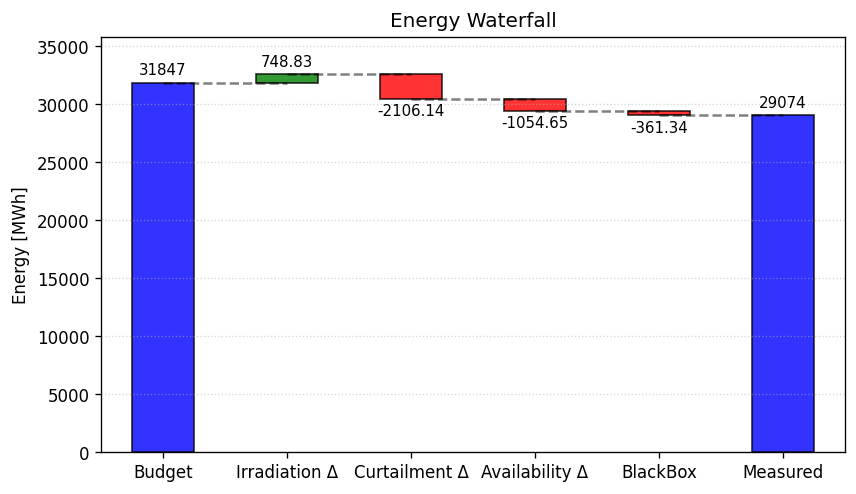

In [6]:
fig = rgp.plot_waterfall(target_date, df_monthly)
all_paths.append(rgp.get_figure_png(fig, "test_files", f"{s_farm_id}_waterfall_{target_date.strftime('%Y-%m')}.png"))

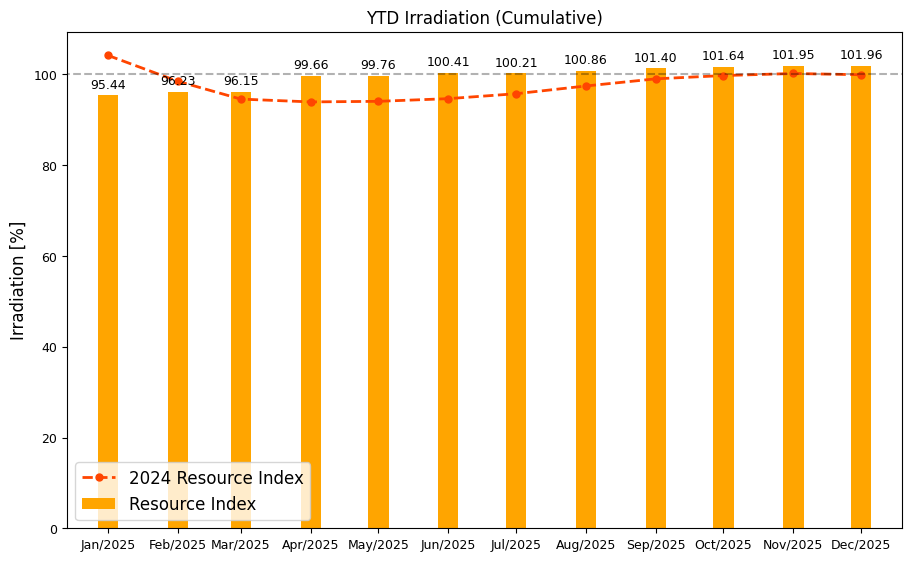

In [7]:
fig = rgp.plot_comparison_ytd(df_monthly, target_date, target="irradiation", percentage=True, cumulative=True)

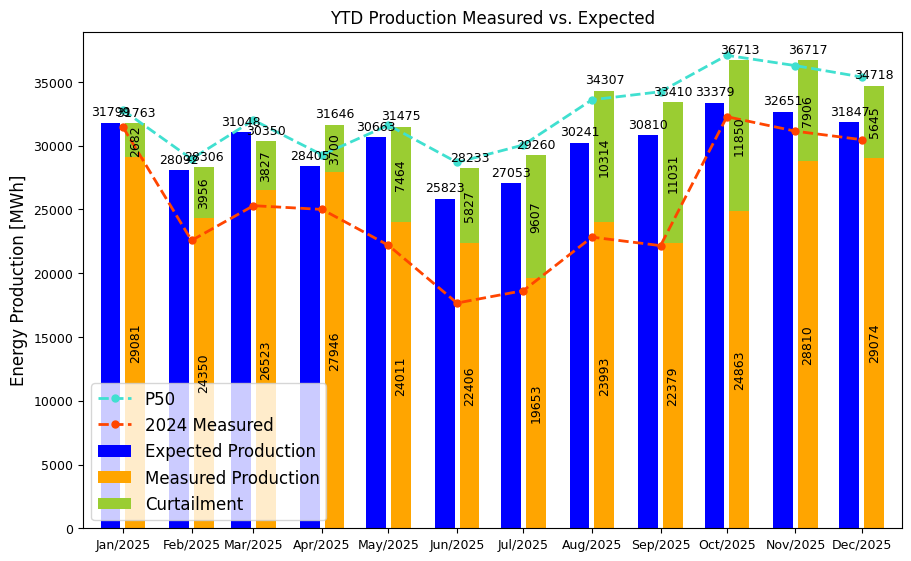

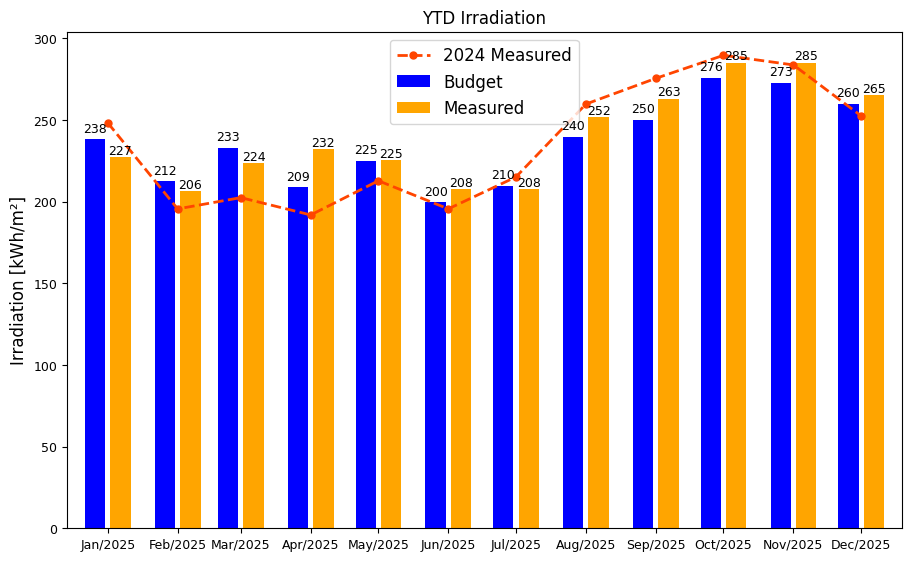

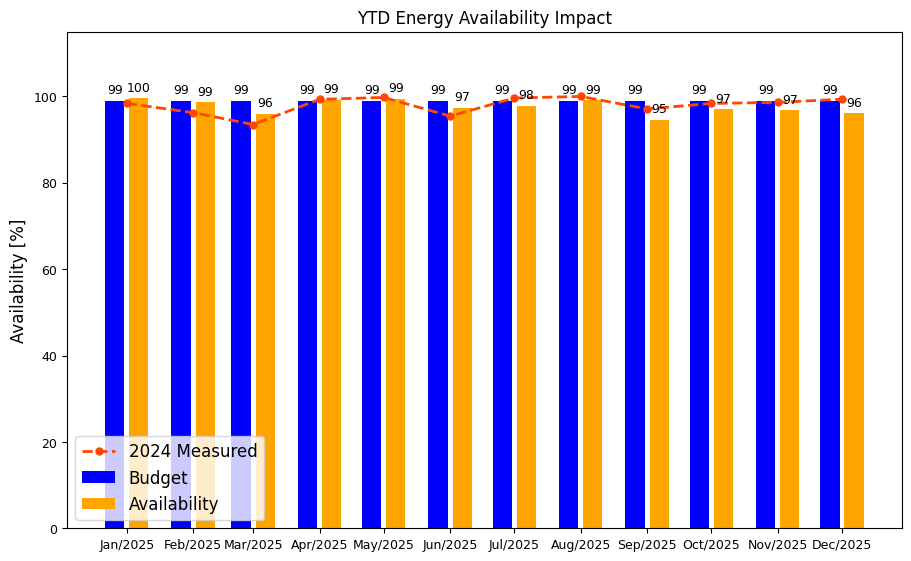

In [8]:
for x in ["production", "irradiation", "availability"]:
    fig = rgp.plot_comparison_ytd(df_monthly, target_date, target=x)
    all_paths.append(rgp.get_figure_png(fig, "test_files", f"{s_farm_id}_comparison_{target_date.strftime('%Y-%m')}_{x}.png"))